In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
merged_df = pd.read_csv("combined.csv")

In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Place_ID         736 non-null    int64  
 1   Place_Name       736 non-null    object 
 2   City             730 non-null    object 
 3   Province         736 non-null    object 
 4   Category         736 non-null    object 
 5   Latitude         736 non-null    float64
 6   Longitude        736 non-null    float64
 7   Terrain_Type     736 non-null    object 
 8   Time_Needed (H)  736 non-null    float64
 9   Rating           736 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 57.6+ KB


<Axes: xlabel='Category'>

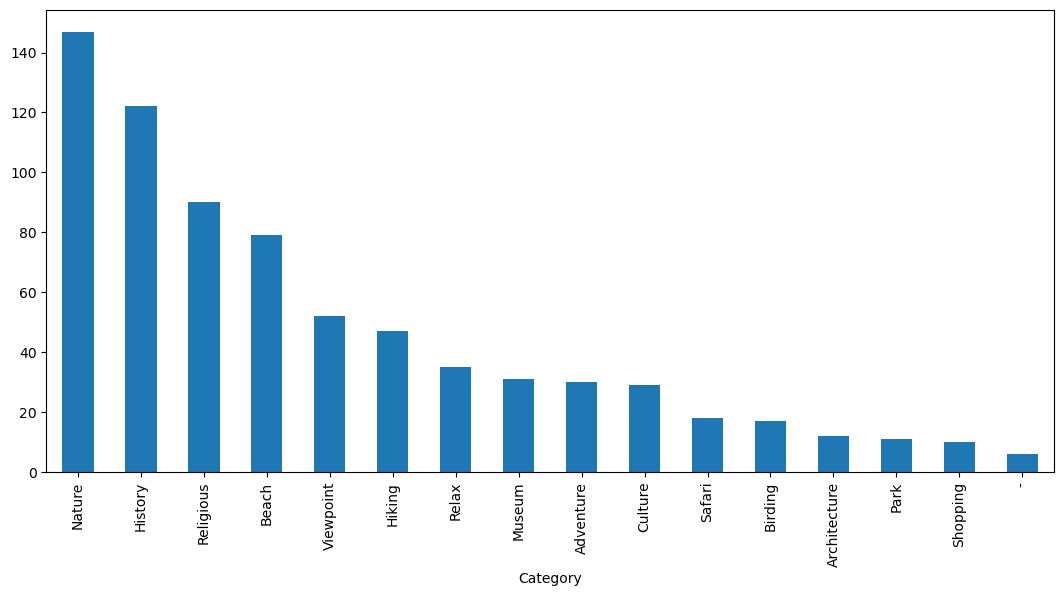

In [4]:
all_type = merged_df["Category"].value_counts()

plt.figure(figsize=(13,6))
all_type.plot(kind="bar")

In [5]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)

    a = (
        math.sin(dlat/2)**2
        + math.cos(math.radians(lat1))
        * math.cos(math.radians(lat2))
        * math.sin(dlon/2)**2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

In [6]:
print(merged_df[["Latitude", "Longitude"]].isnull().sum())

Latitude     0
Longitude    0
dtype: int64


In [7]:
merged_df = merged_df.dropna(subset=["Latitude", "Longitude"])
merged_df[(merged_df["Latitude"] == 0) | (merged_df["Longitude"] == 0)]
merged_df = merged_df[
    (merged_df["Latitude"].between(5.5, 10)) &
    (merged_df["Longitude"].between(79, 82.5))
]

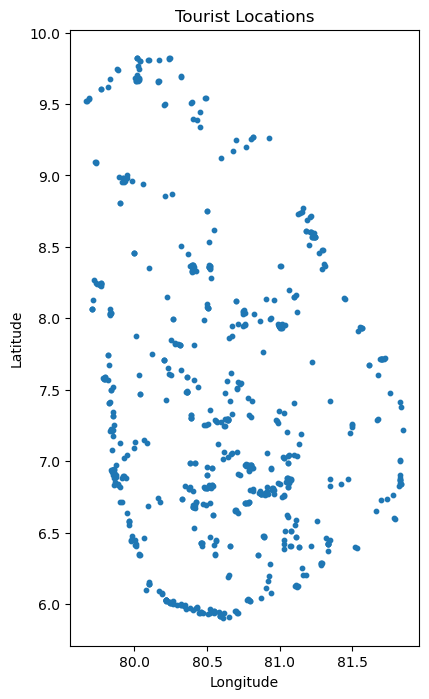

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4.5,8))
plt.scatter(merged_df["Longitude"], merged_df["Latitude"], s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Tourist Locations")
plt.show()

In [9]:
import folium

# center map on Sri Lanka
m = folium.Map(location=[7.8, 80.7], zoom_start=7)

# add points
for _, row in merged_df.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=row["Place_Name"]
    ).add_to(m)

from IPython.display import display
display(m)
m.save("map.html")